# Model 2 — Conventional terrain

Logistic regression on `elevation` and `slope`. `aspect` is named in the shared config and is not in the CSV, so it is not used.

The shared split matches the other experiments. The spatial block split holds out whole 10 by 10 blocks so neighboring cells are not on both sides. The map is every cell, scored by the model fit on the shared training rows. Green is lower susceptibility, red is higher.


In [1]:
import os
import sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from models.exp1_terrain_only_rf import run_model_2

result = run_model_2()


[model_2_conventional] WARNING: TARGET_COL='flood_label' is not in the processed dataset; using 'label'.


[model_2_conventional] metrics saved to /private/tmp/flood-mapping/results/metrics/model_2_conventional_metrics.json
[model_2_conventional] map saved to /private/tmp/flood-mapping/results/maps/model_2_conventional_susceptibility_map.png
  shared_split roc_auc 0.8254 accuracy 0.8313
    confusion_matrix [[248, 362], [124, 2146]]
  spatial_block_split roc_auc 0.8427 accuracy 0.8455
    confusion_matrix [[242, 331], [117, 2210]]


In [2]:
import json

for split_name in ("shared_split", "spatial_block_split"):
    split = result[split_name]
    print(split_name)
    print(json.dumps(split["metrics"], indent=2))
    print("confusion_matrix", split["confusion_matrix"]["matrix"])
    print()


shared_split
{
  "accuracy": 0.83125,
  "precision": 0.8556618819776715,
  "recall": 0.945374449339207,
  "f1_score": 0.8982838007534534,
  "roc_auc": 0.8253820322091429
}
confusion_matrix [[248, 362], [124, 2146]]

spatial_block_split
{
  "accuracy": 0.8455172413793104,
  "precision": 0.8697363242817788,
  "recall": 0.9497206703910615,
  "f1_score": 0.9079704190632704,
  "roc_auc": 0.8426746944398822
}
confusion_matrix [[242, 331], [117, 2210]]



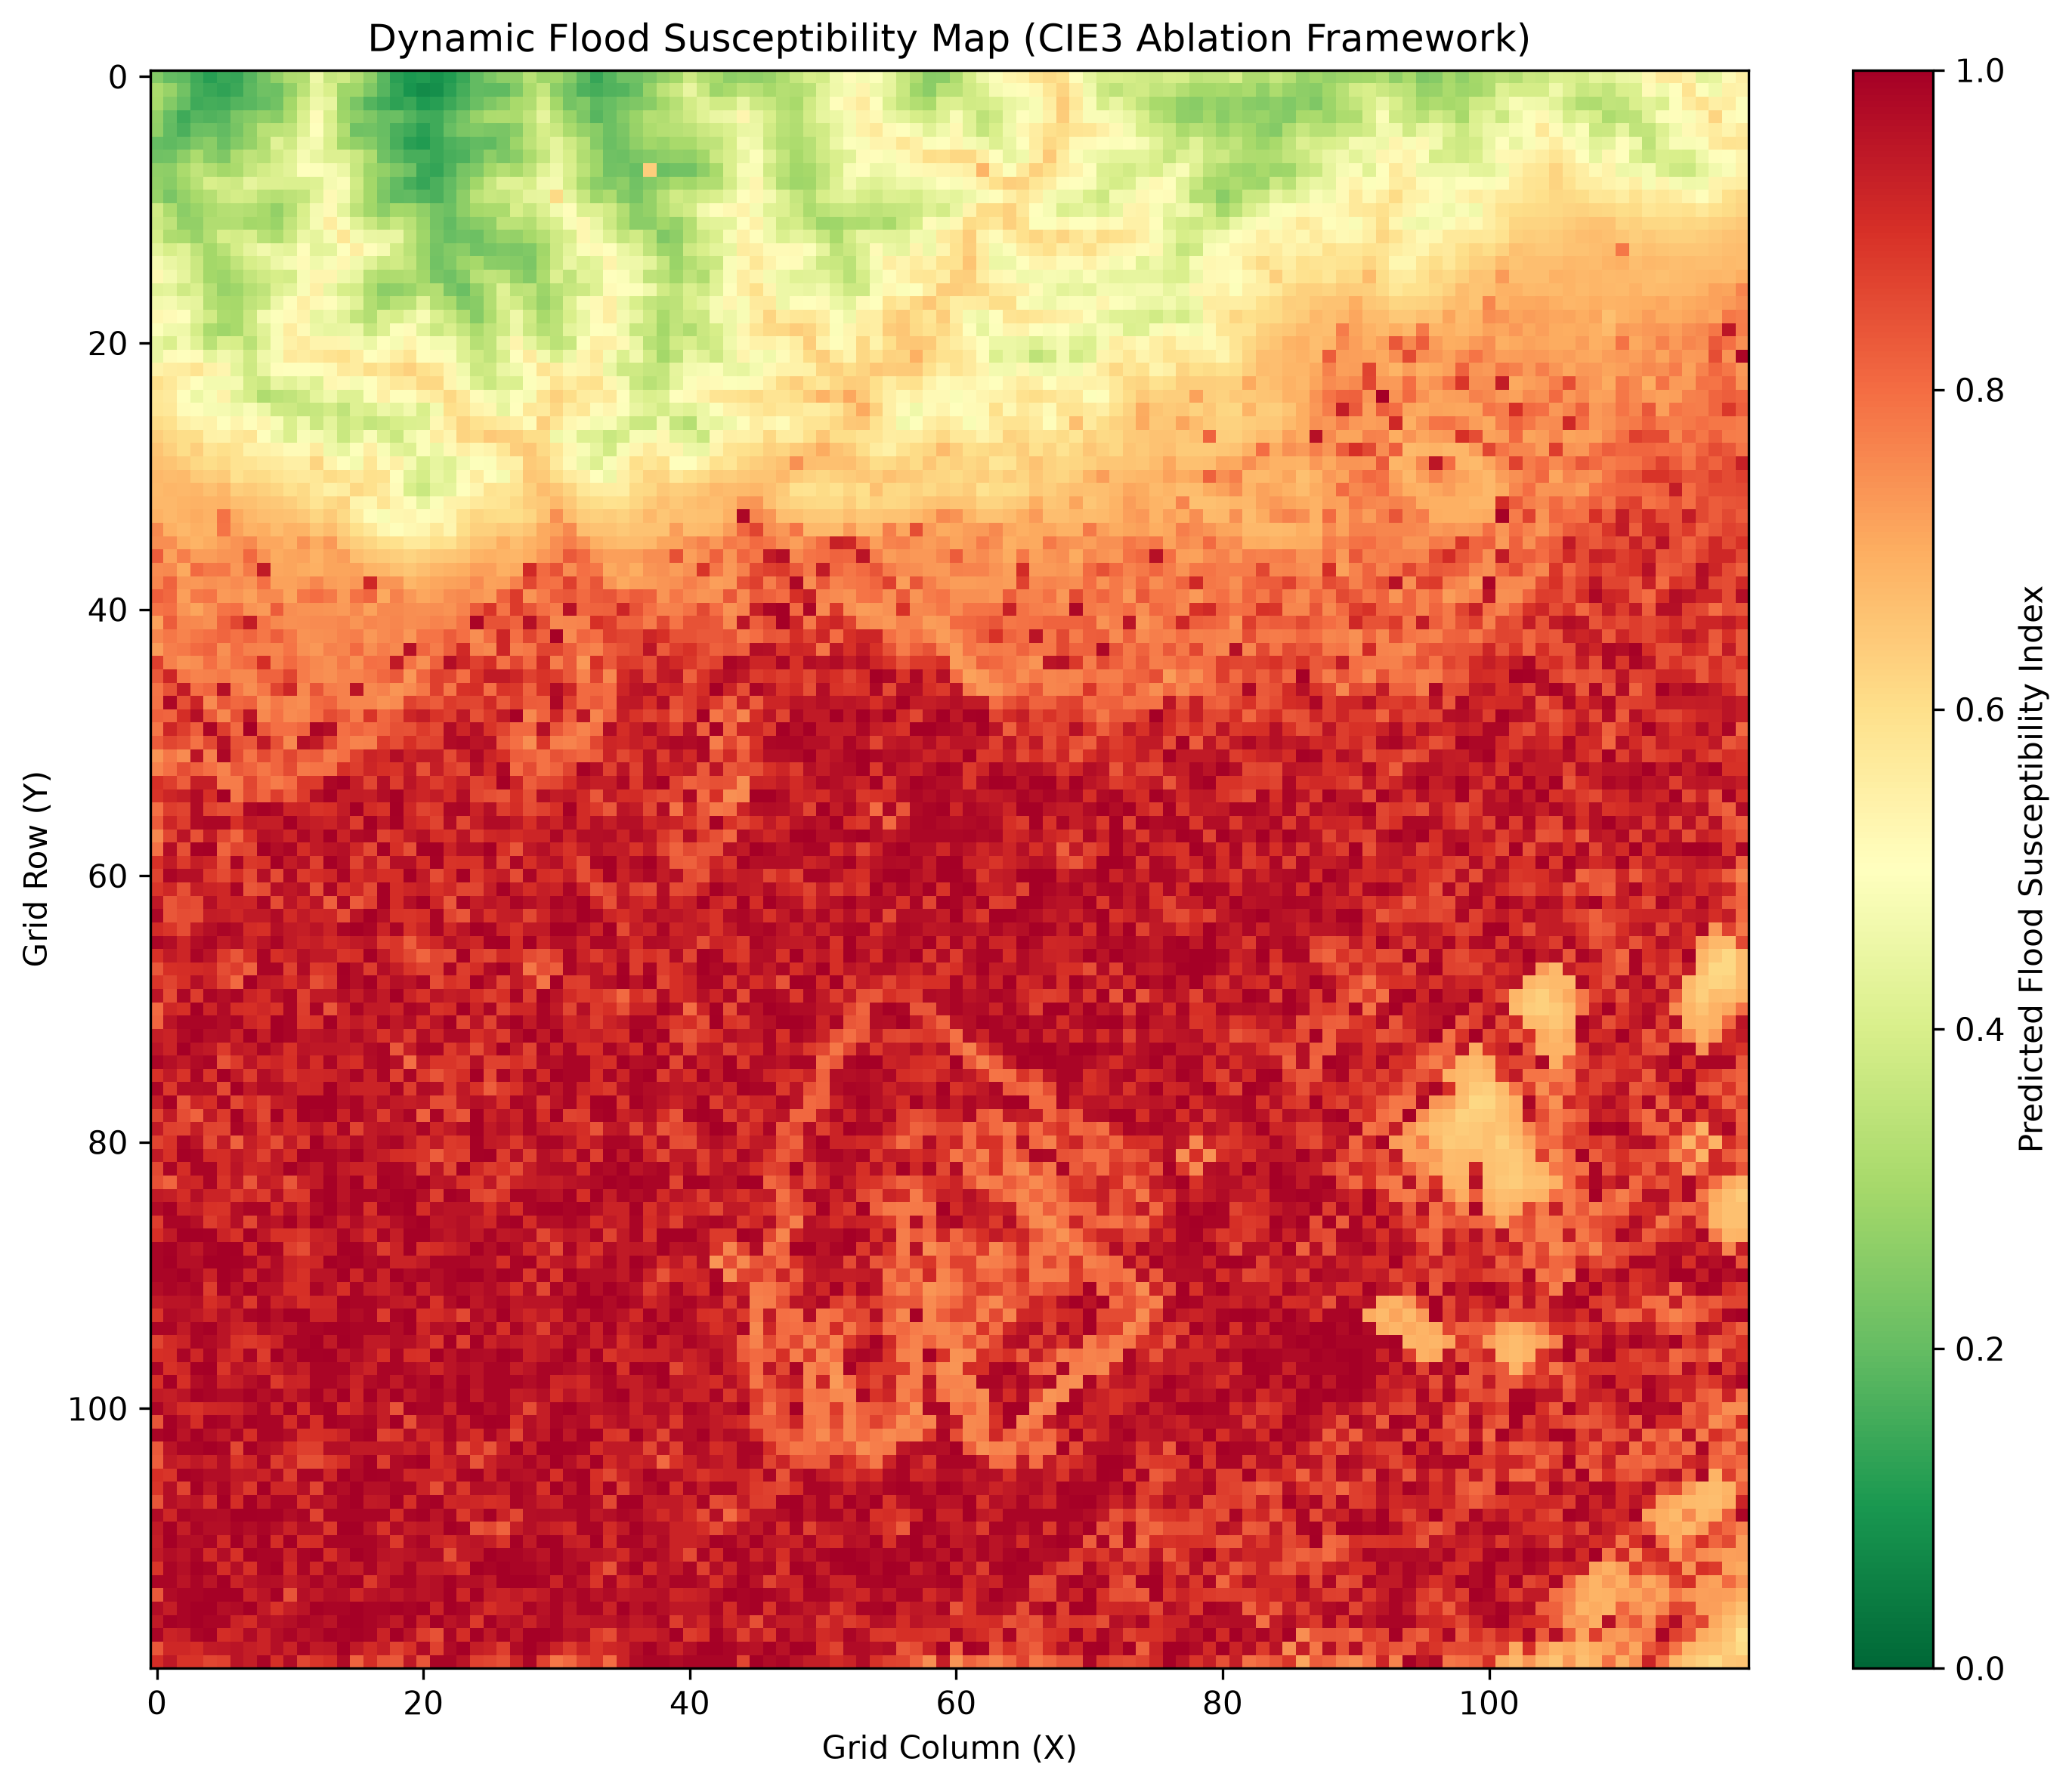

In [3]:
from IPython.display import Image, display

display(Image(filename=result["map"]))
